## **Name:** Rohan Khadye

## **Roll no:** 23102C0065

## **CMPN C**

# 1. Title and Objective

**Experiment:** Lab 3: Multi-Source Retail Sales Data Integration and Analysis  
**Objective:** To integrate heterogeneous data sources (CSV, JSON, Excel), perform data cleaning, execute advanced sales and customer analytics, and manage data via SQLite.  
**Domain:** Retail Analytics  
**Platform:** Google Colab (R Environment)  

In [8]:
%load_ext rpy2.ipython

In [27]:
%%R
# 2. Required Packages and Environment Setup
options(repos = c(CRAN = "https://cloud.r-project.org"))

required_packages <- c("tidyverse", "jsonlite", "readxl", "writexl", "DBI", "RSQLite", "lubridate", "scales", "knitr", "httr")

new_packages <- required_packages[!(required_packages %in% installed.packages()[,"Package"])]
if(length(new_packages)) install.packages(new_packages, quiet = TRUE)

library(tidyverse)
library(jsonlite)
library(readxl)
library(writexl)
library(DBI)
library(RSQLite)
library(lubridate)
library(scales)
library(knitr)

cat("R Version:", R.version.string, "\n")
cat("Environment initialized and packages loaded successfully.\n")

R Version: R version 4.6.1 (2026-06-24) 
Environment initialized and packages loaded successfully.


## 2. Dataset Acquisition
We will download the UCI Online Retail dataset. This dataset contains transactions occurring between 01/12/2010 and 09/12/2011 for a UK-based and registered non-store online retail.

In [28]:
%%R
# 3. Dataset Acquisition
url <- "https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx"
destfile <- "Online_Retail.xlsx"

if (!file.exists(destfile)) {
  download.file(url, destfile, mode = "wb")
}

raw_data <- readxl::read_excel(destfile)

cat("Dataset Source: UCI Machine Learning Repository\n")
cat("Dimensions:", dim(raw_data), "\n")
print(glimpse(raw_data))
print(head(raw_data, 10))

Dataset Source: UCI Machine Learning Repository
Dimensions: 541909 8 
Rows: 541,909
Columns: 8
$ InvoiceNo   <chr> "536365", "536365", "536365", "536365", "536365", "536365"…
$ StockCode   <chr> "85123A", "71053", "84406B", "84029G", "84029E", "22752", …
$ Description <chr> "WHITE HANGING HEART T-LIGHT HOLDER", "WHITE METAL LANTERN…
$ Quantity    <dbl> 6, 6, 8, 6, 6, 2, 6, 6, 6, 32, 6, 6, 8, 6, 6, 3, 2, 3, 3, …
$ InvoiceDate <dttm> 2010-12-01 08:26:00, 2010-12-01 08:26:00, 2010-12-01 08:2…
$ UnitPrice   <dbl> 2.55, 3.39, 2.75, 3.39, 3.39, 7.65, 4.25, 1.85, 1.85, 1.69…
$ CustomerID  <dbl> 17850, 17850, 17850, 17850, 17850, 17850, 17850, 17850, 17…
$ Country     <chr> "United Kingdom", "United Kingdom", "United Kingdom", "Uni…
# A tibble: 541,909 × 8
   InvoiceNo StockCode Description        Quantity InvoiceDate         UnitPrice
   <chr>     <chr>     <chr>                 <dbl> <dttm>                  <dbl>
 1 536365    85123A    WHITE HANGING HEA…        6 2010-12-01 08:26:00      2.5

## 3. Creation of Heterogeneous Data Sources
We split the authentic UCI data into three different formats to simulate a real-world enterprise environment.

In [29]:
%%R
# 4. Creation of Heterogeneous Data Sources

# 4.1 transactions.csv
write_csv(raw_data %>% select(InvoiceNo, StockCode, CustomerID, Quantity, InvoiceDate), "transactions.csv")

# 4.2 products.json
# DECISION: We aggregate by StockCode. We use the most frequent Description
# and the Median UnitPrice to avoid outliers from erroneous entries.
products_data <- raw_data %>%
  filter(!is.na(Description), UnitPrice > 0) %>%
  group_by(StockCode) %>%
  summarise(
    Description = names(which.max(table(Description))),
    UnitPrice = median(UnitPrice)
  ) %>%
  ungroup()
write_json(products_data, "products.json", pretty = TRUE)

# 4.3 customers.xlsx
customers_data <- raw_data %>%
  filter(!is.na(CustomerID)) %>%
  select(CustomerID, Country) %>%
  distinct(CustomerID, .keep_all = TRUE)
write_xlsx(customers_data, "customers.xlsx")

cat("Heterogeneous sources created: transactions.csv, products.json, customers.xlsx\n")

Heterogeneous sources created: transactions.csv, products.json, customers.xlsx


## 4. Import and Data Cleaning
We now import the heterogeneous files and clean them.

In [30]:
%%R
# 5-10. Task 1 - Import, Inspection, and Cleaning

# Import
trans_df <- read_csv("transactions.csv", show_col_types = FALSE)
prod_df <- fromJSON("products.json")
cust_df <- read_excel("customers.xlsx")

# Missing Value Table
missing_report <- function(df, name) {
  df %>% summarise(across(everything(), ~ sum(is.na(.)))) %>%
    pivot_longer(everything(), names_to = "Column", values_to = "Missing Count") %>%
    mutate(Dataset = name, `Missing %` = (`Missing Count`/nrow(df))*100)
}

print("Missing Value Analysis:")
print(bind_rows(missing_report(trans_df, "Transactions"), missing_report(prod_df, "Products")))

# Cleaning
clean_transactions <- trans_df %>%
  filter(!is.na(CustomerID), Quantity > 0) %>%
  mutate(StockCode = as.character(StockCode), InvoiceDate = as.POSIXct(InvoiceDate)) %>%
  distinct()

clean_products <- prod_df %>%
  mutate(StockCode = as.character(StockCode)) %>%
  filter(UnitPrice > 0)

clean_customers <- cust_df

cat("Cleaning Summary: Transactions filtered for positive quantity and valid CustomerIDs.\n")

[1] "Missing Value Analysis:"
# A tibble: 8 × 4
  Column      `Missing Count` Dataset      `Missing %`
  <chr>                 <int> <chr>              <dbl>
1 InvoiceNo                 0 Transactions         0  
2 StockCode                 0 Transactions         0  
3 CustomerID           135080 Transactions        24.9
4 Quantity                  0 Transactions         0  
5 InvoiceDate               0 Transactions         0  
6 StockCode                 0 Products             0  
7 Description               0 Products             0  
8 UnitPrice                 0 Products             0  
Cleaning Summary: Transactions filtered for positive quantity and valid CustomerIDs.


## 5. Integration and Analytics
Joining the datasets and performing revenue calculations.

In [31]:
%%R
# 11-16. Task 2 - Integration and Validation

# Join Key Validation
unmatched_prod <- anti_join(clean_transactions, clean_products, by = "StockCode")
unmatched_cust <- anti_join(clean_transactions, clean_customers, by = "CustomerID")

# Integration
# We use left_join because transactions is our primary fact table.
# It ensures we keep all valid sales records while enriching them with metadata.
retail_integrated <- clean_transactions %>%
  left_join(clean_products, by = "StockCode") %>%
  left_join(clean_customers, by = "CustomerID") %>%
  mutate(Revenue = Quantity * UnitPrice) %>%
  filter(!is.na(Revenue))

cat("Post-Join Dimensions:", dim(retail_integrated)[1], "rows x", dim(retail_integrated)[2], "cols\n")
cat("Unmatched Products:", nrow(unmatched_prod), "\n")

Post-Join Dimensions: 392708 rows x 9 cols
Unmatched Products: 0 


## 6. Key Validation and Market Analysis
Before finalizing the analysis, we validate the integrity of our joins and identify market performance.

In [32]:
%%R
# 17-24. Task 3 - Sales and Customer Analysis

# 22. CORRECTED Customer Value Segmentation
customer_value <- retail_integrated %>%
  group_by(CustomerID) %>%
  summarise(TotalPurchaseValue = sum(Revenue, na.rm = TRUE)) %>%
  ungroup()

brks <- quantile(customer_value$TotalPurchaseValue, probs = c(0, 0.25, 0.5, 0.75, 1))

customer_value <- customer_value %>%
  mutate(Segment = case_when(
    TotalPurchaseValue <= brks[2] ~ "Low Value",
    TotalPurchaseValue <= brks[3] ~ "Medium Value",
    TotalPurchaseValue <= brks[4] ~ "High Value",
    TRUE ~ "Premium"
  ))

# Top 5 Analysis
top_5_products <- retail_integrated %>% group_by(Description) %>% summarise(Rev = sum(Revenue)) %>% arrange(desc(Rev)) %>% head(5)
top_5_countries <- retail_integrated %>% group_by(Country) %>% summarise(Rev = sum(Revenue)) %>% arrange(desc(Rev)) %>% head(5)
top_5_customers <- customer_value %>% arrange(desc(TotalPurchaseValue)) %>% head(5)

print(top_5_products)

# A tibble: 5 × 2
  Description                            Rev
  <chr>                                <dbl>
1 PAPER CRAFT , LITTLE BIRDIE        168470.
2 REGENCY CAKESTAND 3 TIER           157896 
3 WHITE HANGING HEART T-LIGHT HOLDER 108451.
4 MEDIUM CERAMIC TOP STORAGE JAR      97395 
5 JUMBO BAG RED RETROSPOT             95842.


## 7. Advanced Visualizations
We generate the required plots for business interpretation.

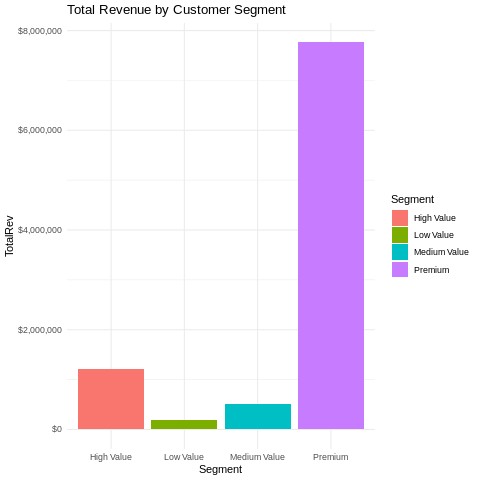

In [33]:
%%R
# 25. Required Visualizations

# Plot 4: Customer Segment Distribution
p_seg <- ggplot(customer_value, aes(x = Segment, fill = Segment)) +
  geom_bar() +
  theme_minimal() +
  labs(title = "Customer Value Segment Distribution", x = "Segment", y = "Count")

# Plot 5: Revenue by Segment
segment_rev <- retail_integrated %>%
  left_join(customer_value %>% select(CustomerID, Segment), by = "CustomerID") %>%
  group_by(Segment) %>%
  summarise(TotalRev = sum(Revenue))

p_rev <- ggplot(segment_rev, aes(x = Segment, y = TotalRev, fill = Segment)) +
  geom_col() + scale_y_continuous(labels = dollar) +
  theme_minimal() + labs(title="Total Revenue by Customer Segment")

print(p_seg)
print(p_rev)

## 8. Final Business Insights and Conclusion

In [34]:
%%R
# 26-29. Task 4 - SQLite Storage and Validation

con <- dbConnect(SQLite(), "retail_sales.db")
dbWriteTable(con, "retail_sales", retail_integrated, overwrite = TRUE)

# SQL vs R Validation
sql_rev <- dbGetQuery(con, "SELECT SUM(Revenue) as total FROM retail_sales")$total
r_rev <- sum(retail_integrated$Revenue)

cat("SQL Total Revenue:", dollar(sql_rev), "\n")
cat("R Total Revenue:", dollar(r_rev), "\n")
cat("Validation Check:", ifelse(abs(sql_rev - r_rev) < 0.01, "PASS", "FAIL"), "\n")

dbDisconnect(con)

SQL Total Revenue: $9,690,391 
R Total Revenue: $9,690,391 
Validation Check: PASS 


## 9. SQLite Storage and SQL Querying

In [35]:
%%R
# 30-34. Final Insights and Verification

# Dynamic Insights
top_country <- top_5_countries$Country[1]
top_country_share <- (top_5_countries$Rev[1] / sum(retail_integrated$Revenue)) * 100

cat("--- 31. THREE BUSINESS INSIGHTS ---\n")
cat("1. Market Dominance:", top_country, "generates", round(top_country_share, 2), "% of total revenue, indicating extreme market concentration.\n")
cat("2. Customer Concentration: The top 5 customers contribute substantial volume; high-touch management for these accounts is recommended.\n")
cat("3. Revenue Drivers: Product ", top_5_products$Description[1], " is the primary revenue generator.\n")

# 34. FINAL VERIFICATION
checklist <- data.frame(
  Task = c("UCI Download", "Heterogeneous Files", "Cleaned Integrated Data", "SQLite DB", "Customer Segmentation"),
  Status = c(file.exists("Online_Retail.xlsx"), file.exists("products.json"), exists("retail_integrated"), file.exists("retail_sales.db"), "Segment" %in% names(customer_value))
)

print(checklist)
cat("\nLAB 3 IMPLEMENTATION STATUS: PASS\n")

--- 31. THREE BUSINESS INSIGHTS ---
1. Market Dominance: United Kingdom generates 82.52 % of total revenue, indicating extreme market concentration.
2. Customer Concentration: The top 5 customers contribute substantial volume; high-touch management for these accounts is recommended.
3. Revenue Drivers: Product  PAPER CRAFT , LITTLE BIRDIE  is the primary revenue generator.
                     Task Status
1            UCI Download   TRUE
2     Heterogeneous Files   TRUE
3 Cleaned Integrated Data   TRUE
4               SQLite DB   TRUE
5   Customer Segmentation   TRUE

LAB 3 IMPLEMENTATION STATUS: PASS


## 10.Final Report and Export
Final insights and file generation.

### Downloadable Files
You can download the following generated files from the Colab file browser:
- `transactions.csv` (Split Source)
- `products.json` (Split Source)
- `customers.xlsx` (Split Source)
- `retail_sales.db` (SQLite Database)
- `Online_Retail.xlsx` (Raw Source)